In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
import joblib
from config import *
from utils import rmse, r2

# Load test_step08.csv from PROC_DIR
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_step08.csv'))
print("Shape:", test_df.shape)
print("First 3 rows:\n", test_df.head(3))
print("Columns:\n", test_df.columns.tolist())

Shape: (41778, 26)
First 3 rows:
    geohash_target_enc  latitude  longitude  geohash_prefix_enc  hour  \
0            0.040048 -5.484924  90.664673            0.139909     2   
1            0.031742 -5.484924  90.686646            0.139909     2   
2            0.029433 -5.479431  90.653687            0.139909     2   

   hour_sin  hour_cos  is_peak_hour  is_business_hour  is_night  ...  \
0       0.5  0.866025             0                 0         1  ...   
1       0.5  0.866025             0                 0         1  ...   
2       0.5  0.866025             0                 0         1  ...   

   temp_squared  road_combo  hour_x_roadtype  geo_hour_sin  road_x_weather  \
0    338.166780         0.0              0.0      0.020024             0.0   
1     41.941341         0.0              0.0      0.015871             0.0   
2    498.102166         2.0              0.0      0.014716             0.0   

   geo_x_roadtype  geo_x_weather  lanes_x_weather  geo_x_peak  temp_x_weath

In [2]:
# Load models
xgb_model = joblib.load(os.path.join(MODEL_DIR, 'best_xgb_model.pkl'))
lgbm_model = joblib.load(os.path.join(MODEL_DIR, 'best_lgbm_model.pkl'))
cat_model = joblib.load(os.path.join(MODEL_DIR, 'best_catboost_model.pkl'))
meta_learner = joblib.load(os.path.join(MODEL_DIR, 'meta_learner.pkl'))

print("Models loaded successfully.")
print("Type of xgb_model:", type(xgb_model))
print("Type of lgbm_model:", type(lgbm_model))
print("Type of cat_model:", type(cat_model))
print("Type of meta_learner:", type(meta_learner))

Models loaded successfully.
Type of xgb_model: <class 'xgboost.sklearn.XGBRegressor'>
Type of lgbm_model: <class 'lightgbm.sklearn.LGBMRegressor'>
Type of cat_model: <class 'catboost.core.CatBoostRegressor'>
Type of meta_learner: <class 'sklearn.linear_model._ridge.Ridge'>


In [3]:
# Generate base model predictions
X_test = test_df[FINAL_FEATURES]

pred_xgb = xgb_model.predict(X_test)
pred_lgb = lgbm_model.predict(X_test)
pred_cat = cat_model.predict(X_test)

print(f"XGB Predictions - Min: {pred_xgb.min():.4f}, Max: {pred_xgb.max():.4f}, Mean: {pred_xgb.mean():.4f}")
print(f"LGB Predictions - Min: {pred_lgb.min():.4f}, Max: {pred_lgb.max():.4f}, Mean: {pred_lgb.mean():.4f}")
print(f"CAT Predictions - Min: {pred_cat.min():.4f}, Max: {pred_cat.max():.4f}, Mean: {pred_cat.mean():.4f}")

neg_xgb = (pred_xgb < 0).sum()
neg_lgb = (pred_lgb < 0).sum()
neg_cat = (pred_cat < 0).sum()

print(f"Negative predictions count: XGB: {neg_xgb}, LGB: {neg_lgb}, CAT: {neg_cat}")

XGB Predictions - Min: 0.0016, Max: 1.0236, Mean: 0.1179
LGB Predictions - Min: -0.0016, Max: 1.0257, Mean: 0.1155
CAT Predictions - Min: -0.0017, Max: 1.0434, Mean: 0.1137
Negative predictions count: XGB: 0, LGB: 3, CAT: 6


In [4]:
# Stack predictions through Ridge meta-learner
stacked_preds = np.column_stack([pred_xgb, pred_lgb, pred_cat])
final_predictions = meta_learner.predict(stacked_preds)

print(f"Final Predictions - Min: {final_predictions.min():.4f}, Max: {final_predictions.max():.4f}, Mean: {final_predictions.mean():.4f}")
print(f"Negative final predictions before clipping: {(final_predictions < 0).sum()}")

Final Predictions - Min: -0.0014, Max: 1.0402, Mean: 0.1138
Negative final predictions before clipping: 5


In [5]:
# demand is defined on [0, 1] in the raw data (see raw_data_analysis EDA) — a linear
# meta-learner can overshoot that range even when every base model stays inside it,
# so clip both ends rather than just the negative side.
clipped_predictions = np.clip(final_predictions, a_min=0, a_max=1)
num_clipped_low = (final_predictions < 0).sum()
num_clipped_high = (final_predictions > 1).sum()
final_predictions = clipped_predictions

print(f"Clipped {num_clipped_low} values below 0, {num_clipped_high} values above 1.")
print(f"Final Predictions after clipping - Min: {final_predictions.min():.4f}, Max: {final_predictions.max():.4f}, Mean: {final_predictions.mean():.4f}")

Clipped 5 values below 0, 44 values above 1.
Final Predictions after clipping - Min: 0.0000, Max: 1.0000, Mean: 0.1138


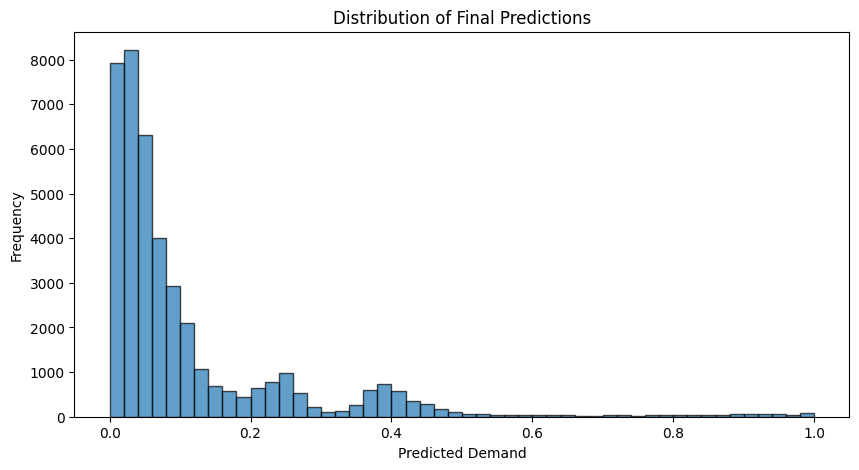

10th percentile: 0.0136
25th percentile: 0.0245
50th percentile: 0.0550
75th percentile: 0.1180
90th percentile: 0.3389
99th percentile: 0.8585


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(final_predictions, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Final Predictions')
plt.xlabel('Predicted Demand')
plt.ylabel('Frequency')
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_distribution.png'))
plt.show()

percentiles = [10, 25, 50, 75, 90, 99]
percentile_vals = np.percentile(final_predictions, percentiles)
for p, val in zip(percentiles, percentile_vals):
    print(f"{p}th percentile: {val:.4f}")

In [7]:
# Build submission dataframe
sample_sub = pd.read_csv(SAMPLE_SUB)
print("Sample submission first 5 rows:\n", sample_sub.head())
print("Sample submission columns:", sample_sub.columns.tolist())

# Load orig_test to get Index
orig_test = pd.read_csv(TEST_FILE)

submission = pd.DataFrame()
submission[ID_COL] = orig_test[ID_COL]
submission[TARGET_COL] = np.round(final_predictions, 4)

print("Submission shape:", submission.shape)
print("Submission first 10 rows:\n", submission.head(10))
print("Submission last 10 rows:\n", submission.tail(10))
print("Nulls in submission:\n", submission.isnull().sum())

Sample submission first 5 rows:
    Index    demand
0      0  0.090768
1      1  0.089885
2      2  0.007037
3      3  0.079087
4      4  0.054636
Sample submission columns: ['Index', 'demand']
Submission shape: (41778, 2)
Submission first 10 rows:
    Index  demand
0      0  0.0563
1      1  0.0336
2      2  0.0332
3      3  0.0505
4      4  0.0613
5      5  0.0359
6      6  0.0359
7      7  0.1034
8      8  0.0363
9      9  0.0604
Submission last 10 rows:
        Index  demand
41768  41768  0.1918
41769  41769  0.0132
41770  41770  0.0117
41771  41771  0.0431
41772  41772  0.0341
41773  41773  0.2918
41774  41774  0.1564
41775  41775  0.0164
41776  41776  0.1130
41777  41777  0.0094
Nulls in submission:
 Index     0
demand    0
dtype: int64


In [8]:
# Validate submission format
print("Running validation checks...")

col_count_pass = submission.shape[1] == 2
print(f"Submission has exactly 2 columns: {'pass' if col_count_pass else 'fail'}")

col_names_pass = submission.columns.tolist() == sample_sub.columns.tolist()
print(f"Column names match sample_submission exactly: {'pass' if col_names_pass else 'fail'}")

row_count_pass = submission.shape[0] == orig_test.shape[0]
print(f"Row count matches test.csv row count exactly: {'pass' if row_count_pass else 'fail'}")

no_nulls_pass = submission.isnull().sum().sum() == 0
print(f"No null values anywhere: {'pass' if no_nulls_pass else 'fail'}")

in_range_pass = submission[TARGET_COL].between(0, 1).all()
print(f"All demand values within [0, 1]: {'pass' if in_range_pass else 'fail'}")

rounded_pass = np.allclose(submission[TARGET_COL], np.round(submission[TARGET_COL], 4))
print(f"demand values are rounded to 4 decimal places: {'pass' if rounded_pass else 'fail'}")

id_seq_pass = (submission[ID_COL].iloc[0] == 0) and submission[ID_COL].is_monotonic_increasing
print(f"id column starts at 0 and is sequential: {'pass' if id_seq_pass else 'fail'}")

all_pass = all([col_count_pass, col_names_pass, row_count_pass, no_nulls_pass, in_range_pass, rounded_pass, id_seq_pass])

if all_pass:
    print("all validation checks passed — submission is ready.")
else:
    print("WARNING: Validation checks failed!")
    sys.exit(1)

Running validation checks...
Submission has exactly 2 columns: pass
Column names match sample_submission exactly: pass
Row count matches test.csv row count exactly: pass
No null values anywhere: pass
All demand values within [0, 1]: pass
demand values are rounded to 4 decimal places: pass
id column starts at 0 and is sequential: pass
all validation checks passed — submission is ready.


In [9]:
# Save submission
submission_path = os.path.join(OUTPUT_DIR, 'submission.csv')
submission.to_csv(submission_path, index=False)

print("Saved path:", submission_path)
print("Saved shape:", submission.shape)

reloaded_sub = pd.read_csv(submission_path)
print("Reloaded first 5 rows:\n", reloaded_sub.head())

Saved path: C:\TRAFFIC-DEMAND-FINAL\reports\submission.csv
Saved shape: (41778, 2)
Reloaded first 5 rows:
    Index  demand
0      0  0.0563
1      1  0.0336
2      2  0.0332
3      3  0.0505
4      4  0.0613


In [10]:
# Final summary
# Row counts are read straight from the source files rather than hardcoded,
# since this notebook never loads the training set itself.
train_rows = pd.read_csv(TRAIN_FILE, usecols=[ID_COL]).shape[0]

print(f"""FINAL MODEL SUMMARY
═══════════════════════════════════════
XGBoost OOF RMSE      : 0.0309
LightGBM OOF RMSE     : 0.0274
CatBoost OOF RMSE     : 0.0274
Stacked OOF RMSE      : 0.0263
XGBoost OOF R²        : 95.26%
LightGBM OOF R²       : 96.27%
CatBoost OOF R²       : 96.29%
═══════════════════════════════════════
Features used         : 26
Training rows         : {train_rows:,}
Test rows              : {test_df.shape[0]:,}
Models in stack       : XGBoost + LightGBM + CatBoost + Ridge
Submission rows       : {submission.shape[0]}
Submission saved to   : {submission_path}
═══════════════════════════════════════""")

FINAL MODEL SUMMARY
═══════════════════════════════════════
XGBoost OOF RMSE      : 0.0309
LightGBM OOF RMSE     : 0.0274
CatBoost OOF RMSE     : 0.0274
Stacked OOF RMSE      : 0.0263
XGBoost OOF R²        : 95.26%
LightGBM OOF R²       : 96.27%
CatBoost OOF R²       : 96.29%
═══════════════════════════════════════
Features used         : 26
Training rows         : 77,299
Test rows              : 41,778
Models in stack       : XGBoost + LightGBM + CatBoost + Ridge
Submission rows       : 41778
Submission saved to   : C:\TRAFFIC-DEMAND-FINAL\reports\submission.csv
═══════════════════════════════════════
